# Control strategy evaluation

Compares four control strategies on the torque-lever simulation:
1. **Constant force** – fixed downward force every timestep
2. **P-controller** – force proportional to angle error
3. **PD-controller** – adds a derivative term (dampens oscillation)
4. **PID-controller** – adds an integral term (eliminates steady-state error)

Each strategy is tuned by a grid search over its parameters. Best parameters are saved to `best_params.json`. **To skip the grid searches and go straight to the comparison figure, run only the first and last cells.**

In [4]:
import json
import jax
import jax.numpy as jp
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from strategies import FixedForce, PIDController
from evaluate import (
    evaluate_strategy, sample_trajectories, plot_trajectory_panel,
    TARGET_DEG,
)

PARAMS_FILE = 'best_params.json'

def load_params():
    with open(PARAMS_FILE) as f:
        return json.load(f)

def save_params(params):
    with open(PARAMS_FILE, 'w') as f:
        json.dump(params, f, indent=2)
    print(f'Saved to {PARAMS_FILE}')

## Grid search: constant force

Vectorised over the force range using `jax.vmap` — runs in one compiled batch.

In [5]:
@jax.jit
@jax.vmap
def eval_fixed_force(force):
    return evaluate_strategy(FixedForce(force))

forces = jp.arange(-5.0, 0.0, 0.01)
scores = eval_fixed_force(forces)

best_force = float(forces[jp.argmax(scores)])
print(f'Best force: {best_force:.3f} N  (score {float(jp.max(scores)):.2f})')

params = load_params()
params['FixedForce'] = {'force': best_force}
save_params(params)

Best force: -2.440 N  (score 5.23)
Saved to best_params.json


## Grid search: P-controller

Single gain `kp`, vectorised with `jax.vmap`.

In [6]:
@jax.jit
@jax.vmap
def eval_p(kp):
    return evaluate_strategy(PIDController(TARGET_DEG, kp=kp))

kp_range = jp.arange(0.0, 20.0, 0.1)
scores = eval_p(kp_range)

best_kp = float(kp_range[jp.argmax(scores)])
print(f'Best kp: {best_kp:.2f}  (score {float(jp.max(scores)):.2f})')

params = load_params()
params['PController'] = {'kp': best_kp}
save_params(params)

Best kp: 9.30  (score 8.71)
Saved to best_params.json


## Grid search: PD-controller

Two gains `kp` and `kd`; Python loop over the grid.

In [8]:
@jax.jit
def eval_pd(kp, kd):
    return evaluate_strategy(PIDController(TARGET_DEG, kp=kp, kd=kd))

best_score, best_kp, best_kd = 0.0, 0.0, 0.0
for kp in tqdm.tqdm(jp.arange(0.0, 25.0, 0.25)):
    for kd in jp.arange(0.0, 1.0, 0.025):
        score = eval_pd(kp, kd)
        if score > best_score:
            best_score, best_kp, best_kd = float(score), float(kp), float(kd)

print(f'Best PD: kp={best_kp:.2f}, kd={best_kd:.2f}  (score {best_score:.2f})')

params = load_params()
params['PDController'] = {'kp': best_kp, 'kd': best_kd}
save_params(params)

100%|██████████| 100/100 [00:37<00:00,  2.69it/s]

Best PD: kp=23.75, kd=0.23  (score 12.48)
Saved to best_params.json


## Grid search: PID-controller

Three gains; Python loop.

In [ ]:
@jax.jit
def eval_pid(kp, ki, kd):
    return evaluate_strategy(PIDController(TARGET_DEG, kp=kp, ki=ki, kd=kd))

best_score, best_kp, best_ki, best_kd = 0.0, 0.0, 0.0, 0.0
for kp in tqdm.tqdm(jp.arange(0.0, 20.0, 0.5)):
    for ki in jp.arange(0.0, 0.2, 0.01):
        for kd in jp.arange(0.0, 2.0, 0.1):
            score = eval_pid(kp, ki, kd)
            if score > best_score:
                best_score = float(score)
                best_kp, best_ki, best_kd = float(kp), float(ki), float(kd)

print(f'Best PID: kp={best_kp:.2f}, ki={best_ki:.3f}, kd={best_kd:.2f}  (score {best_score:.2f})')

params = load_params()
params['PIDController'] = {'kp': best_kp, 'ki': best_ki, 'kd': best_kd}
save_params(params)

## Comparison figure

Each panel shows trajectories under 10 different motor torque levels (colour = torque). The dashed line marks the target angle.

/tmp/ipykernel_164709/3841089663.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


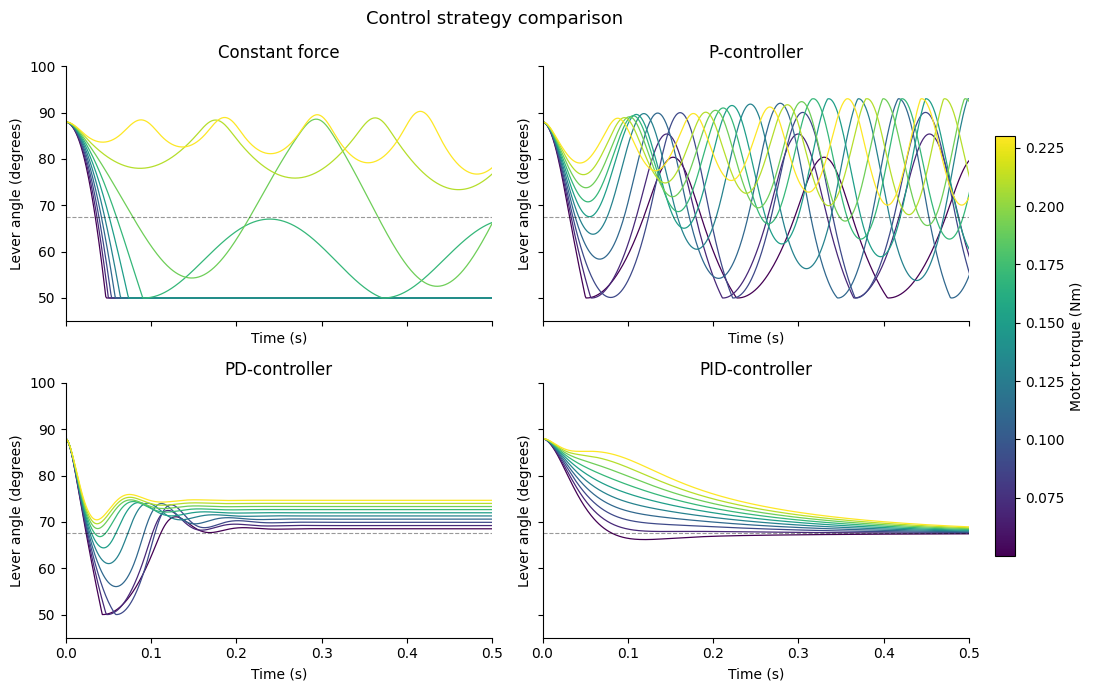

In [20]:
p = load_params()

strategies = [
    ('Constant force',  FixedForce(p['FixedForce']['force'])),
    ('P-controller',    PIDController(TARGET_DEG, kp=p['PController']['kp'])),
    ('PD-controller',   PIDController(TARGET_DEG, kp=p['PDController']['kp'],
                                                  kd=p['PDController']['kd'])),
    ('PID-controller',  PIDController(TARGET_DEG, kp=p['PIDController']['kp'],
                                                  ki=p['PIDController']['ki'],
                                                  kd=p['PIDController']['kd'])),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

sm = None
for ax, (title, strategy) in zip(axes.flat, strategies):
    thetas = sample_trajectories(strategy)
    sm = plot_trajectory_panel(ax, thetas, title)
    ax.set_xlim(0, 0.5)
cax = fig.add_axes([1.0, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cax, label='Motor torque (Nm)')
fig.suptitle('Control strategy comparison', fontsize=13)
plt.tight_layout()
plt.show()